In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 7000

data = []

for _ in range(N):

    # Base signals
    gas = np.random.normal(250, 120)
    temp = np.random.normal(32, 8)
    heart = np.random.normal(80, 20)

    ax, ay, az = np.random.normal(0, 2, 3)
    gx, gy, gz = np.random.normal(0, 30, 3)

    label = 0  # Normal

    # --- WARNING CONDITIONS ---
    if (
        gas > 300 or
        temp > 40 or
        heart > 110
    ):
        label = 1

    # --- FALL / IMPACT ---
    if abs(ax) > 6 or abs(gx) > 150:
        label = 2

    # --- BLAST SHOCKWAVE ---
    if abs(ax) > 12 or abs(gx) > 250:
        label = 2

    # --- SUFFOCATION / LOW OXYGEN ---
    if heart < 55 and abs(ax) < 0.3 and abs(gx) < 5:
        label = 2

    # --- UNCONSCIOUS / IMMOBILE ---
    if abs(ax) < 0.1 and abs(ay) < 0.1 and abs(az) < 0.1:
        label = 2

    # --- FATIGUE ---
    if heart > 100 and abs(ax) < 0.5:
        label = max(label, 1)

    # --- SENSOR TAMPERING ---
    if np.random.rand() < 0.02:  # 2% chance
        ax = ay = az = 0
        gx = gy = gz = 0
        label = 1

    data.append([gas, temp, heart, ax, ay, az, gx, gy, gz, label])

columns = [
    "gas", "temp", "heart",
    "ax", "ay", "az",
    "gx", "gy", "gz",
    "label"
]

df = pd.DataFrame(data, columns=columns)
df.to_csv("mine_safety_dataset_v2.csv", index=False)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())


Dataset shape: (7000, 10)
label
1    3503
0    3471
2      26
Name: count, dtype: int64


In [2]:
import pandas as pd

df = pd.read_csv("mine_safety_dataset_v2.csv")
print(df.head())
print(df["label"].value_counts())


          gas       temp      heart        ax        ay        az         gx  \
0  309.605698  30.893886  92.953771  3.046060 -0.468307 -0.468274  47.376384   
1  315.107205  27.428959  61.518343 -5.225098  1.900739  1.632890 -45.716280   
2  425.877852  30.193790  81.350564 -2.849496 -1.088765  0.221845 -34.529807   
3  214.996750  23.827582  76.764892 -1.067298 -0.011056 -0.458901  11.680467   
4   90.617674  33.574890  94.769332  0.342737 -0.231297 -0.602207 -44.355660   

          gy         gz  label  
0  23.023042 -14.084232      1  
1 -12.841382 -22.272205      1  
2  11.270941 -18.019161      1  
3 -37.953573  32.759768      0  
4 -21.595326 -13.819163      0  
label
1    3503
0    3471
2      26
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (5600, 9)
Test size: (1400, 9)


In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,80
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9878571428571429

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       694
           1       1.00      0.98      0.99       701
           2       1.00      0.20      0.33         5

    accuracy                           0.99      1400
   macro avg       0.99      0.73      0.77      1400
weighted avg       0.99      0.99      0.99      1400


Confusion Matrix:

[[694   0   0]
 [ 13 688   0]
 [  1   3   1]]


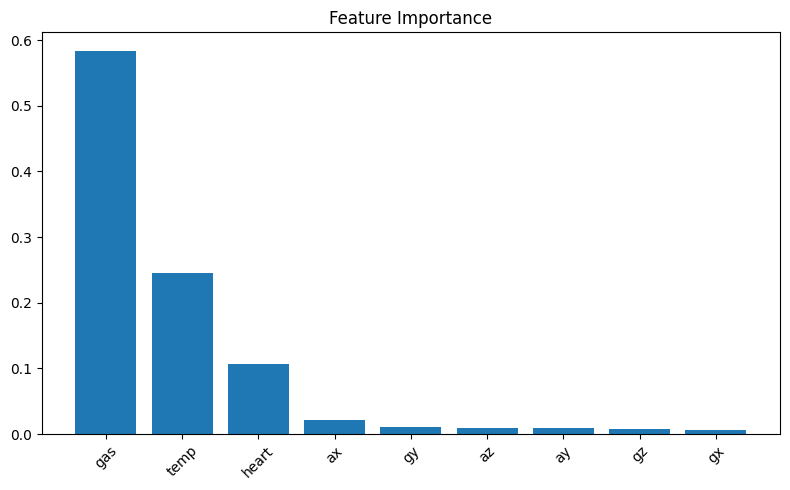

In [6]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=45)
plt.tight_layout()
plt.show()


In [7]:
import joblib

joblib.dump(model, "mine_safety_rf_model.pkl")
print("Model saved.")


Model saved.
